# Exploratory Data Analysis: Telco Customer Churn

Working dataset: `data/Telco-Customer-Churn.csv` (target column: `Churn`, classification).

## 1. Overview

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import DATA_DIR, load_data

sns.set_style("whitegrid")
%matplotlib inline

# Load the raw source CSV explicitly -- load_data()'s default-CSV discovery
# picks the alphabetically-first file in data/, which can resolve to a
# previously generated cleaned.csv once src/data/cleaner.py has run.
df = load_data(DATA_DIR / "Telco-Customer-Churn.csv")

# TotalCharges is read as object dtype because new customers (tenure == 0)
# have a blank string instead of a number; coerce to numeric so downstream
# numeric analysis (distributions, correlation) picks it up correctly.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

target_col = "Churn"
numeric_cols = [c for c in df.select_dtypes(include="number").columns if c != target_col]

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

df.head()

Shape: 7043 rows, 21 columns

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Target Analysis

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


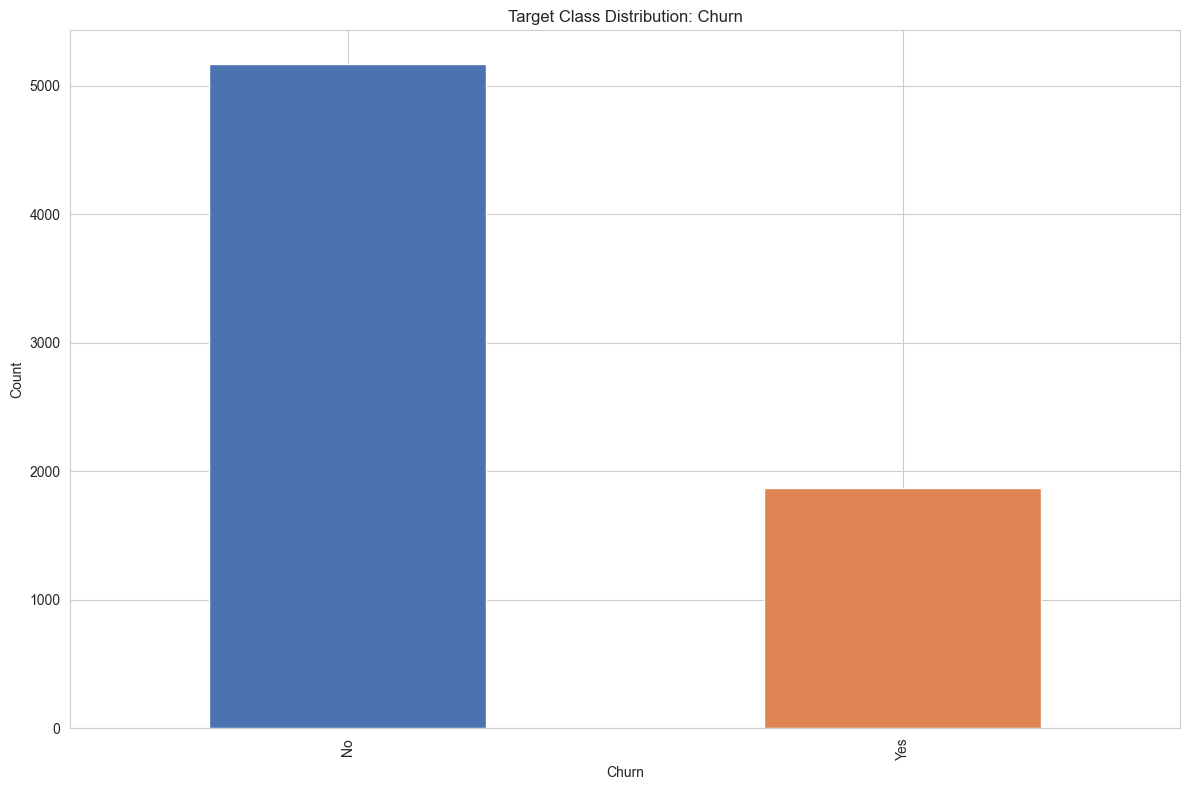

In [2]:
is_classification = df[target_col].dtype == object or df[target_col].nunique() <= 10

if is_classification:
    counts = df[target_col].value_counts()
    pct = (df[target_col].value_counts(normalize=True) * 100).round(2)
    print(counts)
    print()
    print(pct)

    fig, ax = plt.subplots(figsize=(12, 8))
    counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(f"Target Class Distribution: {target_col}")
    ax.set_xlabel(target_col)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print(df[target_col].describe())

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.hist(df[target_col].dropna(), bins=30, color="#4C72B0", edgecolor="black")
    ax.set_title(f"Target Distribution: {target_col}")
    ax.set_xlabel(target_col)
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 3. Missing Values

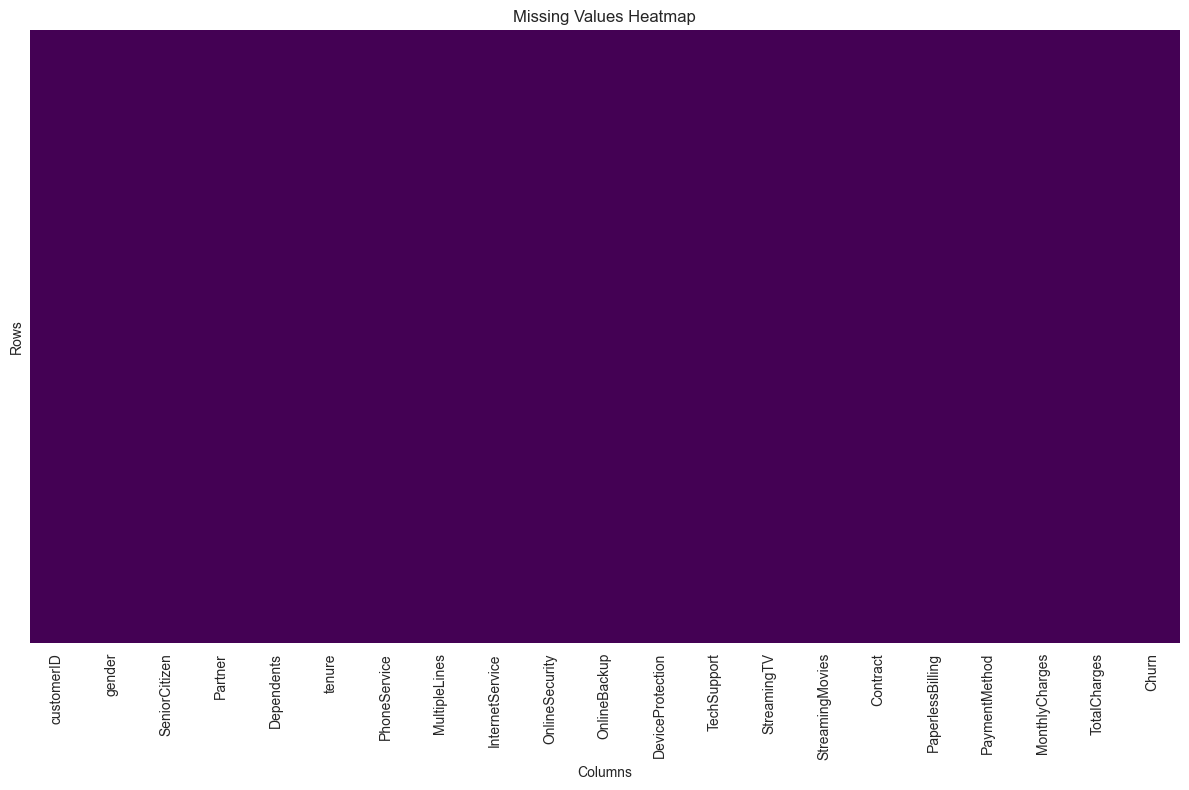

,null_count,null_pct
TotalCharges,11,0.16
gender,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
customerID,0,0.00
Dependents,0,0.00
tenure,0,0.00
MultipleLines,0,0.00
PhoneService,0,0.00
OnlineSecurity,0,0.00


In [3]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing Values Heatmap")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
pd.DataFrame({"null_count": null_counts, "null_pct": null_pct}).sort_values("null_count", ascending=False)

## 4. Feature Distributions

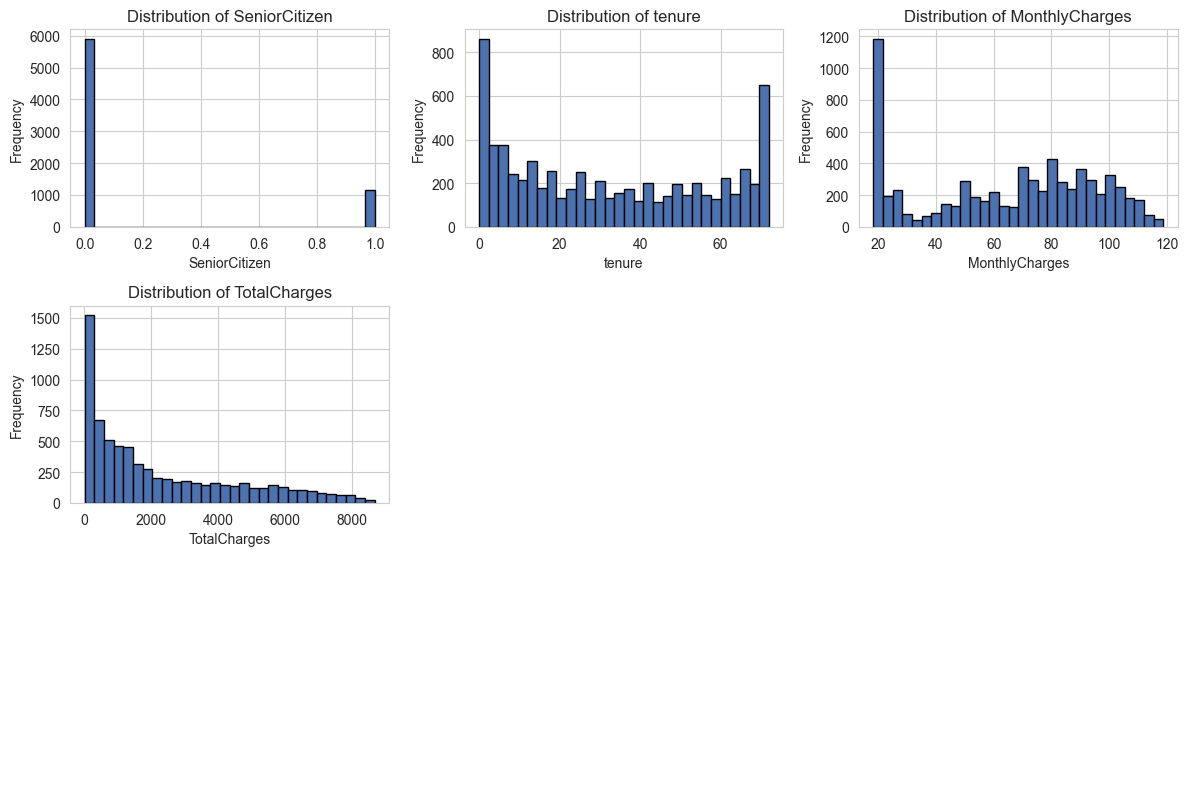

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:9]):
    axes[i].hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(len(numeric_cols), 9):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 5. Correlation Matrix

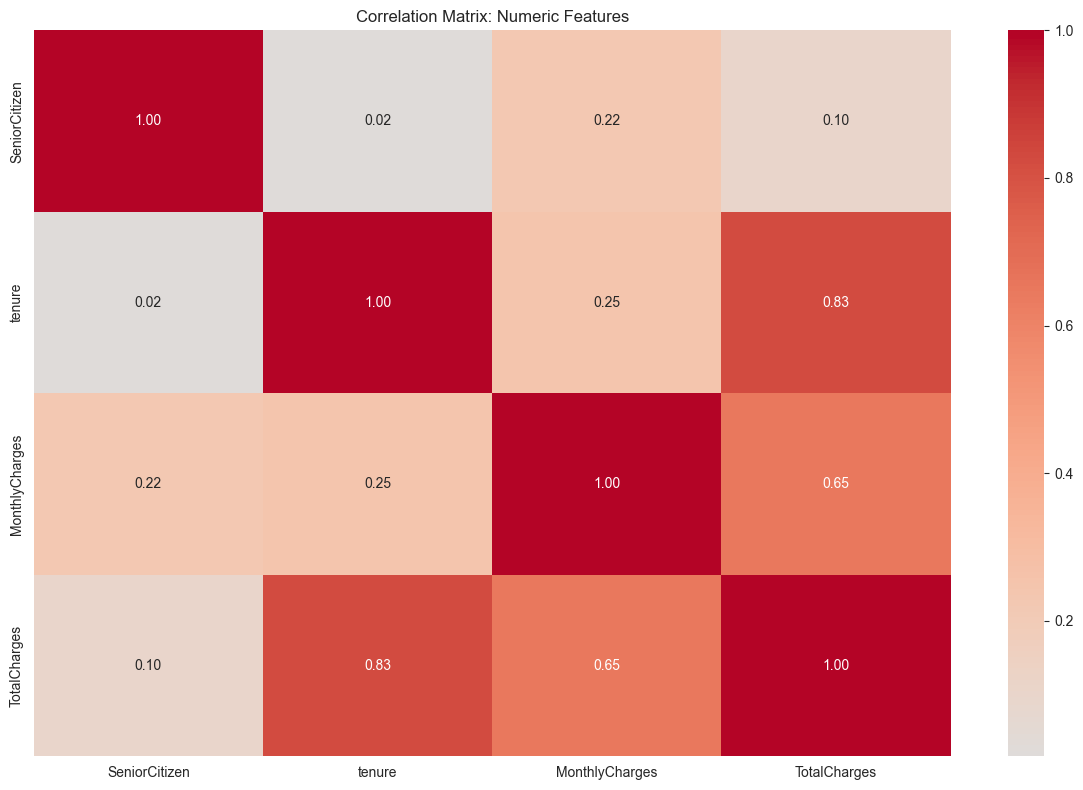

In [5]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix: Numeric Features")
plt.tight_layout()
plt.show()

## 6. Features vs Target

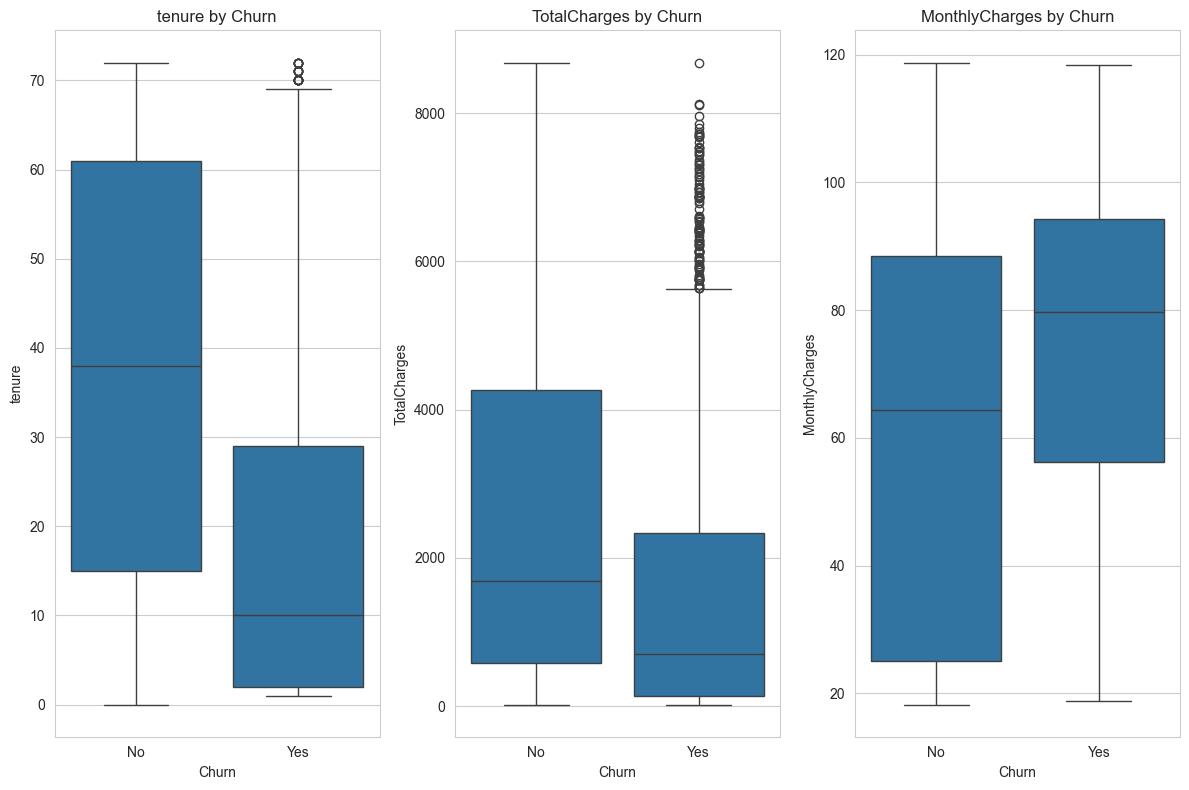

Top features by correlation strength with target:
tenure            0.352
TotalCharges      0.199
MonthlyCharges    0.193
dtype: float64


In [6]:
if is_classification:
    classes = df[target_col].dropna().unique()
    if len(classes) == 2:
        target_numeric = df[target_col].map({classes[0]: 0, classes[1]: 1})
    else:
        target_numeric = df[target_col].astype("category").cat.codes

    correlations = df[numeric_cols].corrwith(target_numeric).abs().sort_values(ascending=False)
    top_features = correlations.head(3).index.tolist()

    fig, axes = plt.subplots(1, 3, figsize=(12, 8))
    for ax, col in zip(axes, top_features):
        sns.boxplot(x=df[target_col], y=df[col], ax=ax)
        ax.set_title(f"{col} by {target_col}")
        ax.set_xlabel(target_col)
        ax.set_ylabel(col)
else:
    correlations = df[numeric_cols].corrwith(df[target_col]).abs().sort_values(ascending=False)
    top_features = correlations.head(3).index.tolist()

    fig, axes = plt.subplots(1, 3, figsize=(12, 8))
    for ax, col in zip(axes, top_features):
        ax.scatter(df[col], df[target_col], alpha=0.5, color="#4C72B0")
        ax.set_title(f"{col} vs {target_col}")
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)

plt.tight_layout()
plt.show()

print("Top features by correlation strength with target:")
print(correlations.head(3).round(3))

## 7. Key Findings

- **Churn rate is 26.5%** (5,174 retained vs 1,869 churned) — imbalanced but not severely so; a majority-class baseline would already hit ~73% accuracy, so model evaluation should rely on precision/recall/F1 rather than accuracy alone.
- **`TotalCharges` has 11 missing values (0.16%)** disguised as blank strings rather than true NaNs — all 11 belong to customers with `tenure == 0` (brand-new accounts that haven't been billed yet); these need explicit handling (impute as 0 or drop) before modeling.
- **`tenure` is the strongest numeric driver of churn** (corr ≈ -0.35): churned customers average ~18 months of tenure vs ~38 months for retained customers — newer customers are far more likely to leave.
- **`tenure` and `TotalCharges` are highly collinear** (corr ≈ 0.83), which makes sense since charges accumulate over time; including both in a linear model risks multicollinearity, so consider dropping one or combining them.
- **Contract type is a much stronger churn signal than any numeric feature**: month-to-month customers churn at 42.7%, versus 11.3% for one-year and just 2.8% for two-year contracts — categorical features like `Contract` (and likely `InternetService`/`PaymentMethod`) deserve at least as much modeling attention as the numeric columns.

## 8. Feature Engineering

In [ ]:
from src.features.engineering import create_features

featured_df = create_features(df)

new_cols = featured_df.columns[df.shape[1]:].tolist()
print(f"Original columns    : {df.shape[1]}")
print(f"Engineered features : {len(new_cols)}")
print(f"Total columns       : {featured_df.shape[1]}")
print()

categories = {
    "Domain-specific": ["is_month_to_month", "num_addon_services", "has_fiber_optic",
                        "uses_auto_payment", "is_new_customer"],
    "Statistical":     ["avg_monthly_spend", "tenure_stage", "monthly_charges_vs_median"],
    "Interactions":    ["high_charge_x_no_contract", "stickiness_score", "charge_per_service"],
}

for cat, cols in categories.items():
    print(f"--- {cat} ---")
    print(featured_df[cols].describe().round(2))
    print()

# Correlation of new features with churn target
target_numeric = (featured_df["Churn"] == "Yes").astype(int)
corr = featured_df[new_cols].corrwith(target_numeric).abs().sort_values(ascending=False)
print("New feature correlations with Churn:")
print(corr.round(3).to_string())

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(new_cols):
    if featured_df[col].nunique() <= 3:
        featured_df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean()).plot(
            kind="bar", ax=axes[i], color="#4C72B0"
        )
        axes[i].set_ylabel("Churn rate")
    else:
        axes[i].boxplot(
            [featured_df.loc[featured_df["Churn"] == v, col].dropna() for v in ["No", "Yes"]],
            labels=["No", "Yes"],
        )
        axes[i].set_ylabel(col)
    axes[i].set_title(col)
    axes[i].set_xlabel("Churn")
for j in range(len(new_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("Engineered Features vs Churn", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()